In [55]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid

import statsmodels.api as sm
import statsmodels.formula.api as smf


tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]

In [56]:
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\4181052062.py:2: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [141]:
print(df_all[['host_id',"in_paris","time"]].value_counts())
df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)

host_id      in_paris  time
33889201.0   1         2406    459
129230780.0  0         2306    353
50502817.0   1         2406    319
314994947.0  1         2406    299
314162972.0  0         2406    298
                              ... 
13095.0      1         2312      1
                       2406      1
18876.0      1         2306      1
                       2312      1
2626.0       1         2306      1
Name: count, Length: 167459, dtype: int64
object


In [142]:
df = df_all.copy()

host_2306 = df[df['time'] == "2306"]['host_id'].to_list()
host_2312 = df[df['time'] == "2312"]['host_id'].to_list()

# sub_df = df[df['time'] != '2306'].copy()

df['is_new_host'] = 0  # 先初始化

# 先选中mask避免覆盖
# 2312 vs 2306
mask_2312 = df['time'] == "2312"
df.loc[mask_2312, 'is_new_host'] = (
    ~df.loc[mask_2312, 'host_id'].isin(host_2306)
).astype(int)

# 2406 vs 2312
mask_2406 = df['time'] == "2406"
df.loc[mask_2406, 'is_new_host'] = (
    ~df.loc[mask_2406, 'host_id'].isin(host_2312)
).astype(int)

print(df[['time', 'is_new_host']].value_counts(dropna=False))

time  is_new_host
2306  0              75257
2406  0              72113
2312  0              57140
2406  1              40481
2312  1              21861
Name: count, dtype: int64


In [143]:
# sub_df['group_pn'] = sub_df.apply(
#     lambda x: f"{'paris' if x['in_paris']==1 else 'london'}_" +
#               f"{'new' if x['is_new_host']==1 else 'old'}",
#     axis=1
# )
# print(sub_df['group_pn'].value_counts(dropna=False))


In [214]:
df_2406=df[df['time']=="2406"]
print(df_2406.shape)
print(df_2406[['time', 'is_new_host']].value_counts())

df_2312=df[df['time']=="2406"]
print(df_2312.shape)
print(df_2312[['time', 'is_new_host']].value_counts())
print(df_2312['time'].dtype)

(112594, 126)
time  is_new_host
2406  0              72113
      1              40481
Name: count, dtype: int64
(112594, 126)
time  is_new_host
2406  0              72113
      1              40481
Name: count, dtype: int64
object


In [ ]:
display(df_2406.groupby(["in_paris", 'is_new_host'])[['booking_rate_l90d','years_since_host']].mean().reset_index())
df_2406.groupby(["in_paris", 'is_new_host'])['host_is_superhost'].value_counts()
display(df_2406.groupby(["in_paris", 'is_new_host'])['host_picture_type'].value_counts(normalize=True).reset_index())
# paris 2024显然更高比例的portrait


,in_paris,is_new_host,booking_rate_l90d,years_since_host
0,0,0,0.113584,6.708754
1,0,1,0.138104,5.397936
2,1,0,0.085889,7.061330
3,1,1,0.064405,6.567747


,in_paris,is_new_host,host_picture_type,proportion
0,0,0,no_person,0.383900
1,0,0,pro_style,0.322060
2,0,0,life_style,0.294040
3,0,1,pro_style,0.344828
4,0,1,no_person,0.339878
5,0,1,life_style,0.315295
6,1,0,no_person,0.380794
7,1,0,pro_style,0.347817
8,1,0,life_style,0.271389
9,1,1,pro_style,0.432358


In [ ]:
times=['2312', "2406"]
in_paris=[0]

df_t=df.copy()

df_t = df_t[df_t['time'].isin(times)]
df_t = df_t[df_t['in_paris'].isin(in_paris)]

print(df.shape, '=>', df_t.shape)
df_t[['time','in_paris']].value_counts()


df_

(266852, 126) => (93028, 126)


time  in_paris
2406  0           49856
2312  0           43172
Name: count, dtype: int64

In [206]:
from scipy import stats

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''
    
def ttest_new_old(df, times: list=["2012"], in_paris=[0, 1], vars=tactics_bio):
    
    # check time & in_paris
    df_t=df.copy()
        
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]


    # if times:
    #     df_t = df_t[df_t['time'].isin(times)]
    # if in_paris:
    #     df_t=df_t[df_t['in_paris'].isin(in_paris)]

    print(df.shape, '=>', df_t.shape)
    
    groups_in_paris=df_t['in_paris'].unique()
    groups_time=df_t['time'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for time in groups_time:    
        for p in groups_in_paris:        
            for var in vars:
                new = df_t[df_t['is_new_host'] == 1][var].dropna()
                old = df_t[df_t['is_new_host'] == 0][var].dropna()

                t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)
                sig=p_to_sig(p_value)
                
                row_new= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':1,
                    'mean':[new.mean()],
                    'label':f"{var} {sig}"

                })
                row_old= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':0,
                    'mean':[old.mean()],
                    'label':f"{var} {sig}"
                })
                rows.append(row_new)
                rows.append(row_old)
    return pd.concat(rows, axis=0)
    
# df_plot_2406=ttest_new_old(df, times=["2406"], in_paris=[0,1], vars=tactics_bio)
# df_plot_2406
     
df_plot_2312=ttest_new_old(df, times=["2312"], in_paris=[0,1], vars=tactics_bio)
df_plot_2312


(266852, 126) => (79001, 126)


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,20.600008,6.901734e-94,***,1,-0.028430,ouverture ***
0,2312,0,ouverture,20.600008,6.901734e-94,***,0,-0.125702,ouverture ***
0,2312,0,authenticité,33.087132,1.612202e-237,***,1,-0.061219,authenticité ***
0,2312,0,authenticité,33.087132,1.612202e-237,***,0,-0.229009,authenticité ***
0,2312,0,sociabilité,7.043315,1.901689e-12,***,1,-0.044242,sociabilité ***
0,2312,0,sociabilité,7.043315,1.901689e-12,***,0,-0.079002,sociabilité ***
0,2312,0,auto_promotion,-36.935661,1.043835e-294,***,1,0.019935,auto_promotion ***
0,2312,0,auto_promotion,-36.935661,1.043835e-294,***,0,0.208010,auto_promotion ***
0,2312,0,exemplarité,-9.036303,1.677097e-19,***,1,0.000006,exemplarité ***
0,2312,0,exemplarité,-9.036303,1.677097e-19,***,0,0.043161,exemplarité ***


dict_keys(['nouveaux hôtes(Londres)', 'anciens hôtes(Londres)', 'nouveaux hôtes(Paris)', 'anciens hôtes(Paris)'])


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\1027786454.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\1027786454.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


Text(0.5, 1.02, 'Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Juin 2024')

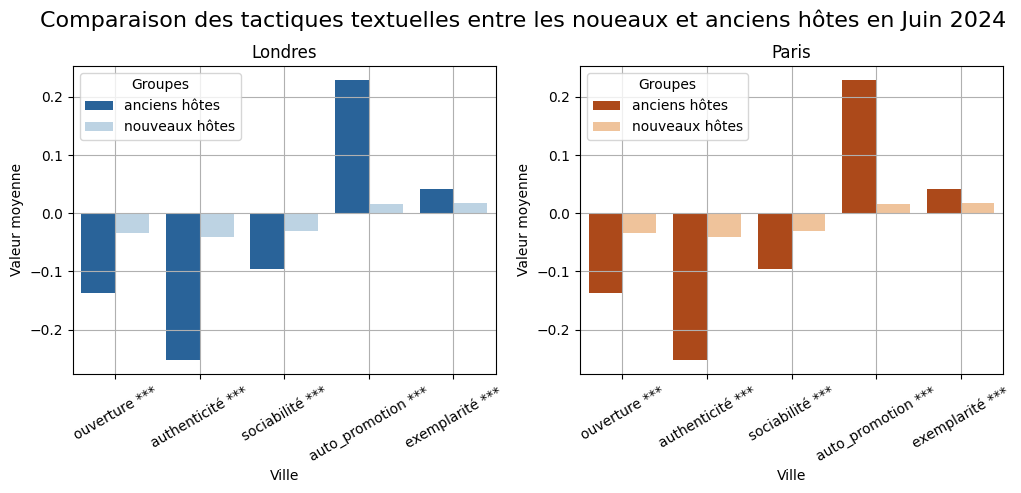

In [ ]:
## 2406 london + paris new vs old
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

df_plot=df_plot_2406.copy()

# # group
# df_plot['group'] = df_plot.apply(
#     lambda x: f"{'nouveaux hôtes' if x['is_new_host']==1 else 'anciens hôtes'}"
#         f"{'(Paris)' if x['in_paris']==1 else '(Londres)'}"
#     ,axis=1
# )
# groups=df_plot['group'].unique()
# palette={k: v for k, v in zip (groups, colors)}
# print(palette.keys())


## ---layout 2facets----
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 4)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.4, wspace=0.2)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])

for i, p in enumerate(df_plot['in_paris'].unique()):
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    if p==1:
        palette=dict(zip(sub['is_new_host'], paris_colors))
    else :
        palette=dict(zip(sub['is_new_host'], london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue="is_new_host",
        palette=palette,
        order=order_tactics,
        ax=ax,
        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    # variable
    #     ouverture         ***
    #     authenticité      ***
    #     sociabilité       ***
    #     auto_promotion    ***
    #     exemplarité       ***
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, new_labels, title="Groupes")
    ax.grid()

plt.suptitle("Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Juin 2024", fontsize=16,y=1.02)#y提高大标题和图之间的距离



dict_keys(['nouveaux hôtes(Londres)', 'anciens hôtes(Londres)', 'nouveaux hôtes(Paris)', 'anciens hôtes(Paris)'])


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\1127187746.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\1127187746.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


Text(0.5, 1.02, 'Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Décembre 2024')

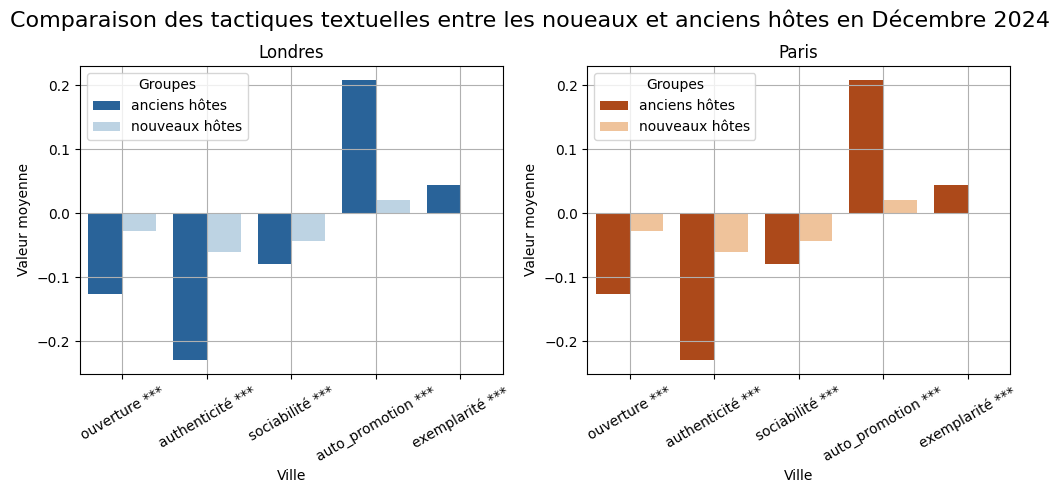

In [ ]:
## 2312 london + paris new vs old
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
# #649BC8
colors = (
    list(london_colors) +
    list(paris_colors)
)

df_plot=df_plot_2312.copy()

# group
df_plot['group'] = df_plot.apply(
    lambda x: f"{'nouveaux hôtes' if x['is_new_host']==1 else 'anciens hôtes'}"
        f"{'(Paris)' if x['in_paris']==1 else '(Londres)'}"
    ,axis=1
)
groups=df_plot['group'].unique()
palette={k: v for k, v in zip (groups, colors)}
print(palette.keys())


## ---layout 2facets----
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 4)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.4, wspace=0.2)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])

for i, p in enumerate(df_plot['in_paris'].unique()):
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    if p==1:
        palette=dict(zip(sub['is_new_host'], paris_colors))
    else :
        palette=dict(zip(sub['is_new_host'], london_colors))
   
    sns.barplot(
        data=sub,   # 用 df_long（不是 df_stats）
        x='variable',
        y="mean",
        hue="is_new_host",
        palette=palette,
        order=order_tactics,
        ax=ax,
        
    )
    
    # ax.set_xticklabels([
    #     f"{var} {sig}".strip()
    #     for var, sig in zip(sub['variable'], sub['sig'])
    # ])
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    # variable
    #     ouverture         ***
    #     authenticité      ***
    #     sociabilité       ***
    #     auto_promotion    ***
    #     exemplarité       ***
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, new_labels, title="Groupes")
    ax.grid()

plt.suptitle("Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Décembre 2024", fontsize=16,y=1.02)#y提高大标题和图之间的距离



In [ ]:
## 2406 london + paris superhost vs autres
# df['host_is_superhost']=df['host_is_superhost'].apply(lambda x : 1 if x=="t" else 0)
# print(df['host_is_superhost'].value_counts())


def ttest_superhost(df, times: list=["2012"], in_paris=[0, 1], vars=tactics_bio):
    # check time & in_paris
    df_t=df.copy()
        
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]


    # if times:
    #     df_t = df_t[df_t['time'].isin(times)]
    # if in_paris:
    #     df_t=df_t[df_t['in_paris'].isin(in_paris)]

    print(df.shape, '=>', df_t.shape)
    
    groups_in_paris=df_t['in_paris'].unique()
    groups_time=df_t['time'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for time in groups_time:    
        for p in groups_in_paris:        
            for var in vars:
                new = df_t[df_t['host_is_superhost'] == 1][var].dropna()
                old = df_t[df_t['host_is_superhost'] == 0][var].dropna()

                t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)
                sig=p_to_sig(p_value)
                
                row_new= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'host_is_superhost':1,
                    'mean':[new.mean()],
                    'label':f"{var} {sig}"
                })
                
                row_old= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'host_is_superhost':0,
                    'mean':[old.mean()],
                    'label':f"{var} {sig}"
                })
                rows.append(row_new)
                rows.append(row_old)
    return pd.concat(rows, axis=0)
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot_superhost=ttest_superhost(df, times=["2406"], in_paris=[0,1], vars=order_tactics)
display(df_plot_superhost)



(266852, 126) => (112594, 126)


,time,in_paris,variable,t_stat,p_value,sig,host_is_superhost,mean,label
0,2406,0,ouverture,13.669108,1.967541e-42,***,1,-0.047247,ouverture ***
0,2406,0,ouverture,13.669108,1.967541e-42,***,0,-0.114409,ouverture ***
0,2406,0,authenticité,20.017348,1.071799e-88,***,1,-0.096355,authenticité ***
0,2406,0,authenticité,20.017348,1.071799e-88,***,0,-0.199053,authenticité ***
0,2406,0,sociabilité,20.321556,2.499288e-91,***,1,0.005565,sociabilité ***
0,2406,0,sociabilité,20.321556,2.499288e-91,***,0,-0.095200,sociabilité ***
0,2406,0,auto_promotion,-2.945416,3.227126e-03,**,1,0.140856,auto_promotion **
0,2406,0,auto_promotion,-2.945416,3.227126e-03,**,0,0.156102,auto_promotion **
0,2406,0,exemplarité,7.737135,1.042151e-14,***,1,0.064404,exemplarité ***
0,2406,0,exemplarité,7.737135,1.042151e-14,***,0,0.024819,exemplarité ***


,time,in_paris,variable,t_stat,p_value,sig,host_is_superhost,mean,label
0,2406,0,ouverture,13.669108,1.967541e-42,***,1,-0.047247,ouverture ***
0,2406,0,ouverture,13.669108,1.967541e-42,***,0,-0.114409,ouverture ***
0,2406,0,authenticité,20.017348,1.071799e-88,***,1,-0.096355,authenticité ***
0,2406,0,authenticité,20.017348,1.071799e-88,***,0,-0.199053,authenticité ***
0,2406,0,sociabilité,20.321556,2.499288e-91,***,1,0.005565,sociabilité ***
0,2406,0,sociabilité,20.321556,2.499288e-91,***,0,-0.095200,sociabilité ***
0,2406,0,auto_promotion,-2.945416,3.227126e-03,**,1,0.140856,auto_promotion **
0,2406,0,auto_promotion,-2.945416,3.227126e-03,**,0,0.156102,auto_promotion **
0,2406,0,exemplarité,7.737135,1.042151e-14,***,1,0.064404,exemplarité ***
0,2406,0,exemplarité,7.737135,1.042151e-14,***,0,0.024819,exemplarité ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\4090035515.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


,time,in_paris,variable,t_stat,p_value,sig,host_is_superhost,mean,label
0,2406,1,ouverture,13.669108,1.967541e-42,***,1,-0.047247,ouverture ***
0,2406,1,ouverture,13.669108,1.967541e-42,***,0,-0.114409,ouverture ***
0,2406,1,authenticité,20.017348,1.071799e-88,***,1,-0.096355,authenticité ***
0,2406,1,authenticité,20.017348,1.071799e-88,***,0,-0.199053,authenticité ***
0,2406,1,sociabilité,20.321556,2.499288e-91,***,1,0.005565,sociabilité ***
0,2406,1,sociabilité,20.321556,2.499288e-91,***,0,-0.095200,sociabilité ***
0,2406,1,auto_promotion,-2.945416,3.227126e-03,**,1,0.140856,auto_promotion **
0,2406,1,auto_promotion,-2.945416,3.227126e-03,**,0,0.156102,auto_promotion **
0,2406,1,exemplarité,7.737135,1.042151e-14,***,1,0.064404,exemplarité ***
0,2406,1,exemplarité,7.737135,1.042151e-14,***,0,0.024819,exemplarité ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\4090035515.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


Text(0.5, 1.02, 'Comparaison des tactiques textuelles entre les Superhôtes et autres en Décembre 2024')

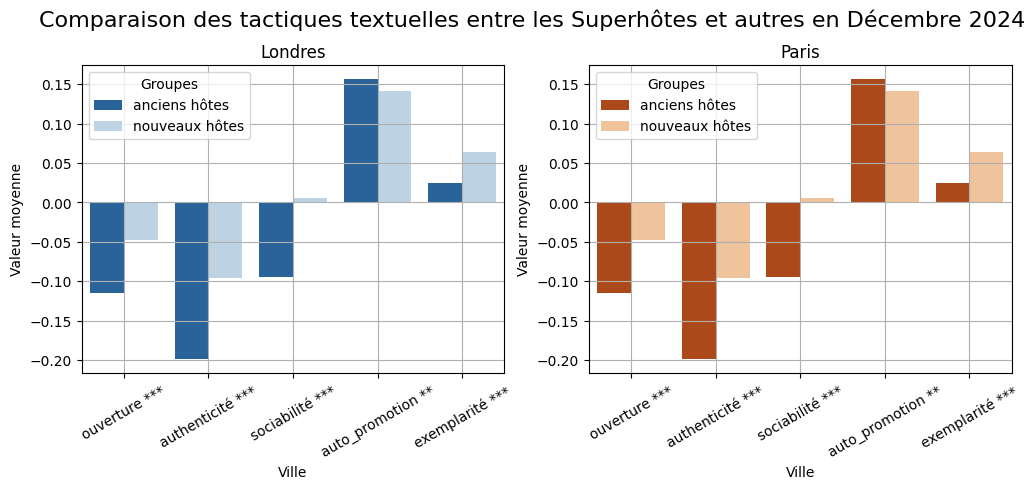

In [213]:



# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

df_plot=df_plot_superhost.copy()

# # group
# df_plot['group'] = df_plot.apply(
#     lambda x: f"{'nouveaux hôtes' if x['is_new_host']==1 else 'anciens hôtes'}"
#         f"{'(Paris)' if x['in_paris']==1 else '(Londres)'}"
#     ,axis=1
# )
# groups=df_plot['group'].unique()
# palette={k: v for k, v in zip (groups, colors)}
# print(palette.keys())


## ---layout 2facets----
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 4)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.4, wspace=0.2)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])

for i, p in enumerate(df_plot['in_paris'].unique()):#分图
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    display(sub)
    
    hue_col="host_is_superhost"
    if p==1:
        palette=dict(zip(sub[hue_col].unique(), paris_colors))
    else :
        palette=dict(zip(sub[hue_col].unique(), london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue=hue_col,
        palette=palette,
        order=order_tactics,
        ax=ax,
        
    )
   
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, new_labels, title="Groupes")
    ax.grid()

plt.suptitle("Comparaison des tactiques textuelles entre les Superhôtes et autres en Décembre 2024", fontsize=16,y=1.02)#y提高大标题和图之间的距离


In [202]:
## title:all new 
# group : london+paris 
# hue : 2312 vs 2406

def ttest_by_time(df, times: list=["2012"], in_paris=[0, 1], is_new_host=[1], vars=tactics_bio):
    
    # ---data---
    df_t=df.copy()        
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]
    df_t = df_t[df_t['is_new_host'].isin(is_new_host)]
    print(df.shape, '=>', df_t.shape)
    print(df_t[['is_new_host','time', "in_paris"]].value_counts(dropna=False))
    groups_in_paris=df_t['in_paris'].unique()
    groups_new_host=df_t['is_new_host'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for new in groups_new_host: # 统一
        for p in groups_in_paris: #分图 
            for var in vars:
                # hue
                early = df_t[df_t['time'] == "2312"][var].dropna()
                late = df_t[df_t['time'] == "2406"][var].dropna()
                
                t_stat, p_value = stats.ttest_ind(early, late, equal_var=False)
                sig=p_to_sig(p_value)
                
                row_early= pd.DataFrame({
                    "time": ["2312"],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':new,
                    'mean':[early.mean()],
                    'label':f"{var} {sig}"

                })
                row_late= pd.DataFrame({
                    "time": ["2406"],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':new,
                    'mean':[late.mean()],
                    'label':f"{var} {sig}"
                })
                rows.append(row_early)
                rows.append(row_late)
    return pd.concat(rows, axis=0)

df_plot_new=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[1], vars=tactics_bio)
df_plot_new


(266852, 126) => (62342, 126)
is_new_host  time  in_paris
1            2406  1           28562
                   0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,1.127544,0.259519,,1,-0.028430,ouverture
0,2406,0,ouverture,1.127544,0.259519,,1,-0.033688,ouverture
0,2312,0,authenticité,-4.111629,0.000039,***,1,-0.061219,authenticité ***
0,2406,0,authenticité,-4.111629,0.000039,***,1,-0.041143,authenticité ***
0,2312,0,sociabilité,-2.914725,0.003562,**,1,-0.044242,sociabilité **
0,2406,0,sociabilité,-2.914725,0.003562,**,1,-0.030233,sociabilité **
0,2312,0,auto_promotion,0.705939,0.480230,,1,0.019935,auto_promotion
0,2406,0,auto_promotion,0.705939,0.480230,,1,0.016465,auto_promotion
0,2312,0,exemplarité,-3.719639,0.000200,***,1,0.000006,exemplarité ***
0,2406,0,exemplarité,-3.719639,0.000200,***,1,0.018094,exemplarité ***


0


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,1.127544,0.259519,,1,-0.028430,ouverture
0,2406,0,ouverture,1.127544,0.259519,,1,-0.033688,ouverture
0,2312,0,authenticité,-4.111629,0.000039,***,1,-0.061219,authenticité ***
0,2406,0,authenticité,-4.111629,0.000039,***,1,-0.041143,authenticité ***
0,2312,0,sociabilité,-2.914725,0.003562,**,1,-0.044242,sociabilité **
0,2406,0,sociabilité,-2.914725,0.003562,**,1,-0.030233,sociabilité **
0,2312,0,auto_promotion,0.705939,0.480230,,1,0.019935,auto_promotion
0,2406,0,auto_promotion,0.705939,0.480230,,1,0.016465,auto_promotion
0,2312,0,exemplarité,-3.719639,0.000200,***,1,0.000006,exemplarité ***
0,2406,0,exemplarité,-3.719639,0.000200,***,1,0.018094,exemplarité ***


1


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\735597480.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,1.127544,0.259519,,1,-0.028430,ouverture
0,2406,1,ouverture,1.127544,0.259519,,1,-0.033688,ouverture
0,2312,1,authenticité,-4.111629,0.000039,***,1,-0.061219,authenticité ***
0,2406,1,authenticité,-4.111629,0.000039,***,1,-0.041143,authenticité ***
0,2312,1,sociabilité,-2.914725,0.003562,**,1,-0.044242,sociabilité **
0,2406,1,sociabilité,-2.914725,0.003562,**,1,-0.030233,sociabilité **
0,2312,1,auto_promotion,0.705939,0.480230,,1,0.019935,auto_promotion
0,2406,1,auto_promotion,0.705939,0.480230,,1,0.016465,auto_promotion
0,2312,1,exemplarité,-3.719639,0.000200,***,1,0.000006,exemplarité ***
0,2406,1,exemplarité,-3.719639,0.000200,***,1,0.018094,exemplarité ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\735597480.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


Text(0.5, 1.02, 'Comparaison des tactiques textuelles entre les noueaux hôtes en Déc 2023 et Juin 2024')

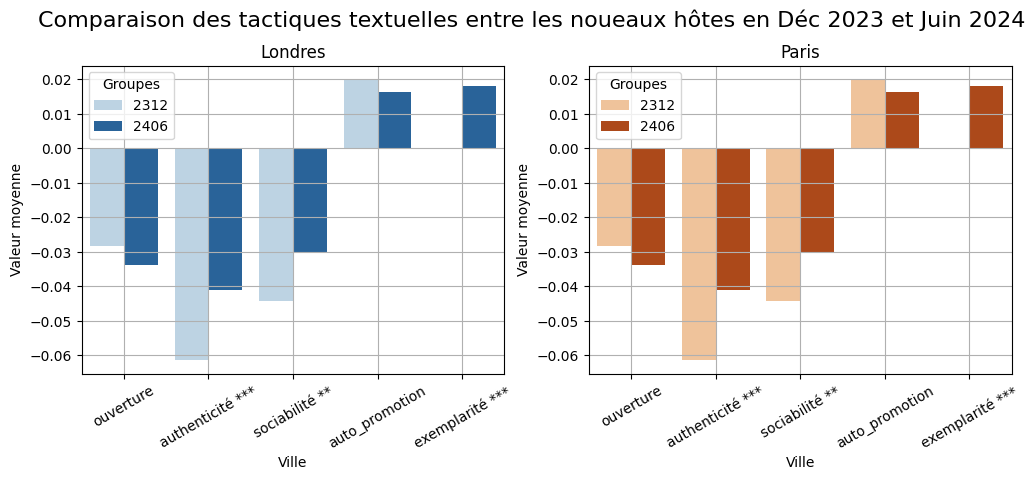

In [203]:
## new 2312& 2406?

order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
# #649BC8
colors = (
    list(london_colors) +
    list(paris_colors)
)

df_plot=df_plot_new.copy()

## ---layout 2facets----
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 4)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.4, wspace=0.2)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])

for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    display(sub)
    
    if p==1:# hue：分柱子的颜色
        palette=dict(zip(sub['time'].unique(), paris_colors))
    else :
        palette=dict(zip(sub['time'].unique(), london_colors))
    
        
    sns.barplot(
        data=sub, 
        x='variable',
        y="mean",
        hue="time",# hue
        palette=palette,
        order=order_tactics,
        ax=ax,        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    # legend的分组
    handles, labels = ax.get_legend_handles_labels()
    # labels = ["Dec 2023", ""]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()

plt.suptitle("Comparaison des tactiques textuelles entre les noueaux hôtes en Déc 2023 et Juin 2024", fontsize=16,y=1.02)#y提高大标题和图之间的距离



(266852, 126) => (129253, 126)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
                   1           24780
Name: count, dtype: int64
0


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,2.772419,5.564972e-03,**,0,-0.125702,ouverture **
0,2406,0,ouverture,2.772419,5.564972e-03,**,0,-0.136340,ouverture **
0,2312,0,authenticité,5.419249,5.996204e-08,***,0,-0.229009,authenticité ***
0,2406,0,authenticité,5.419249,5.996204e-08,***,0,-0.251942,authenticité ***
0,2312,0,sociabilité,4.354090,1.337292e-05,***,0,-0.079002,sociabilité ***
0,2406,0,sociabilité,4.354090,1.337292e-05,***,0,-0.096589,sociabilité ***
0,2312,0,auto_promotion,-5.020617,5.157847e-07,***,0,0.208010,auto_promotion ***
0,2406,0,auto_promotion,-5.020617,5.157847e-07,***,0,0.229180,auto_promotion ***
0,2312,0,exemplarité,0.199342,8.419956e-01,,0,0.043161,exemplarité
0,2406,0,exemplarité,0.199342,8.419956e-01,,0,0.042375,exemplarité


1


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\1546761266.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,2.772419,5.564972e-03,**,0,-0.125702,ouverture **
0,2406,1,ouverture,2.772419,5.564972e-03,**,0,-0.136340,ouverture **
0,2312,1,authenticité,5.419249,5.996204e-08,***,0,-0.229009,authenticité ***
0,2406,1,authenticité,5.419249,5.996204e-08,***,0,-0.251942,authenticité ***
0,2312,1,sociabilité,4.354090,1.337292e-05,***,0,-0.079002,sociabilité ***
0,2406,1,sociabilité,4.354090,1.337292e-05,***,0,-0.096589,sociabilité ***
0,2312,1,auto_promotion,-5.020617,5.157847e-07,***,0,0.208010,auto_promotion ***
0,2406,1,auto_promotion,-5.020617,5.157847e-07,***,0,0.229180,auto_promotion ***
0,2312,1,exemplarité,0.199342,8.419956e-01,,0,0.043161,exemplarité
0,2406,1,exemplarité,0.199342,8.419956e-01,,0,0.042375,exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\1546761266.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


Text(0.5, 1.02, 'Comparaison des tactiques textuelles entre les anciens hôtes en Déc 2023 et Juin 2024')

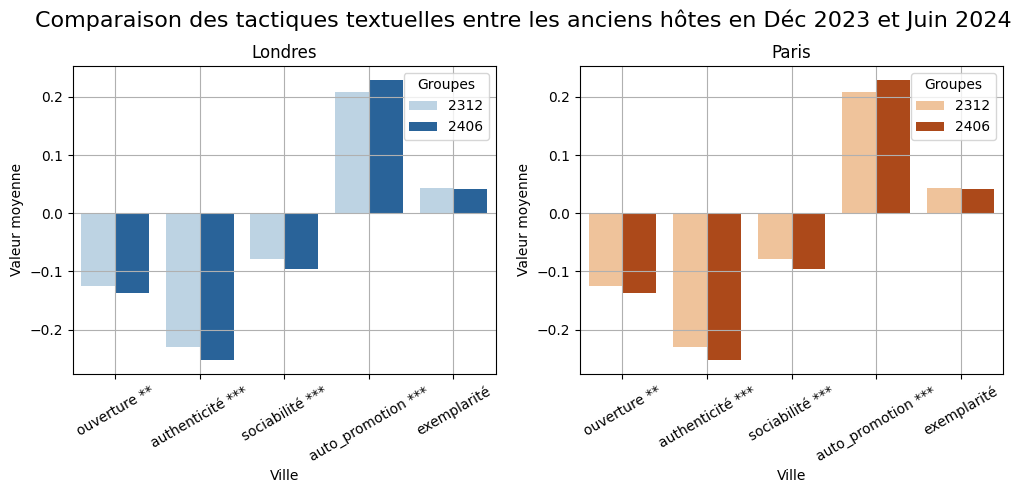

In [204]:
## OLD 2312& 2406?
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

df_plot_new=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[0], vars=tactics_bio)
df_plot_new


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
# #649BC8
colors = (
    list(london_colors) +
    list(paris_colors)
)

df_plot=df_plot_new.copy()

## ---layout 2facets----
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 4)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.4, wspace=0.2)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])

for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    display(sub)
    
    if p==1:# hue：分柱子的颜色
        palette=dict(zip(sub['time'].unique(), paris_colors))
    else :
        palette=dict(zip(sub['time'].unique(), london_colors))
    
        
    sns.barplot(
        data=sub, 
        x='variable',
        y="mean",
        hue="time",# hue
        palette=palette,
        order=order_tactics,
        ax=ax,        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    # legend的分组
    handles, labels = ax.get_legend_handles_labels()
    # labels = ["Dec 2023", ""]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()
plt.suptitle("Comparaison des tactiques textuelles entre les anciens hôtes en Déc 2023 et Juin 2024", fontsize=16,y=1.02)#y提高大标题和图之间的距离


group
nouveaux hôtes(Londres)    5
anciens hôtes(Londres)     5
nouveaux hôtes(Paris)      5
anciens hôtes(Paris)       5
Name: count, dtype: int64


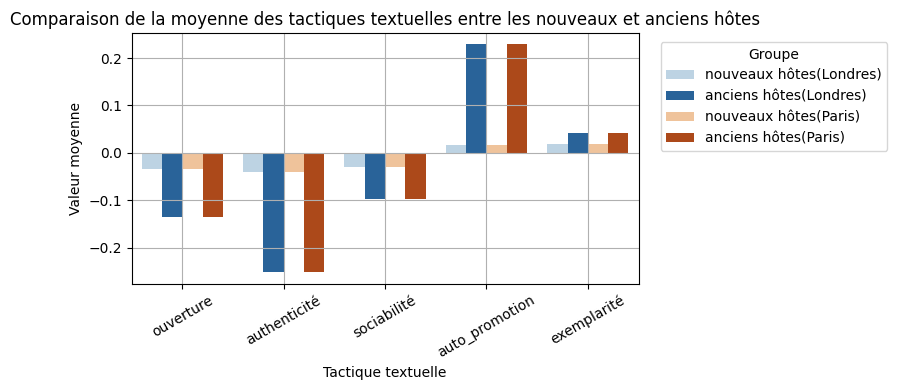

In [88]:
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot['group'] = df_plot.apply(
    lambda x: f"{'nouveaux hôtes' if x['is_new_host']==1 else 'anciens hôtes'}"
        f"{'(Paris)' if x['in_paris']==1 else '(Londres)'}"
    ,axis=1
)
print(df_plot['group'].value_counts(dropna=False))

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

groups=df_plot['group'].unique()
palette={k: v for k, v in zip (groups, colors)}



fig, ax=plt.subplots(figsize=(6,4))

sns.barplot(
    data=df_plot,   # 用 df_long（不是 df_stats）
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=order_tactics,
    # errorbar="sd",
    ax=ax
)


ax.set_title("Comparaison de la moyenne des tactiques textuelles entre les nouveaux et anciens hôtes")
ax.set_xlabel("Tactique textuelle")
ax.set_ylabel("Valeur moyenne")
ax.tick_params(axis="x",rotation=30)
ax.get_legend().remove()

handles, labels=ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Groupe",  loc="upper left", bbox_to_anchor=(1, 0.9))
ax.grid()
plt.tight_layout(rect=[0, 0, 1, 1])


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\2060331927.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0, 0.9,1])


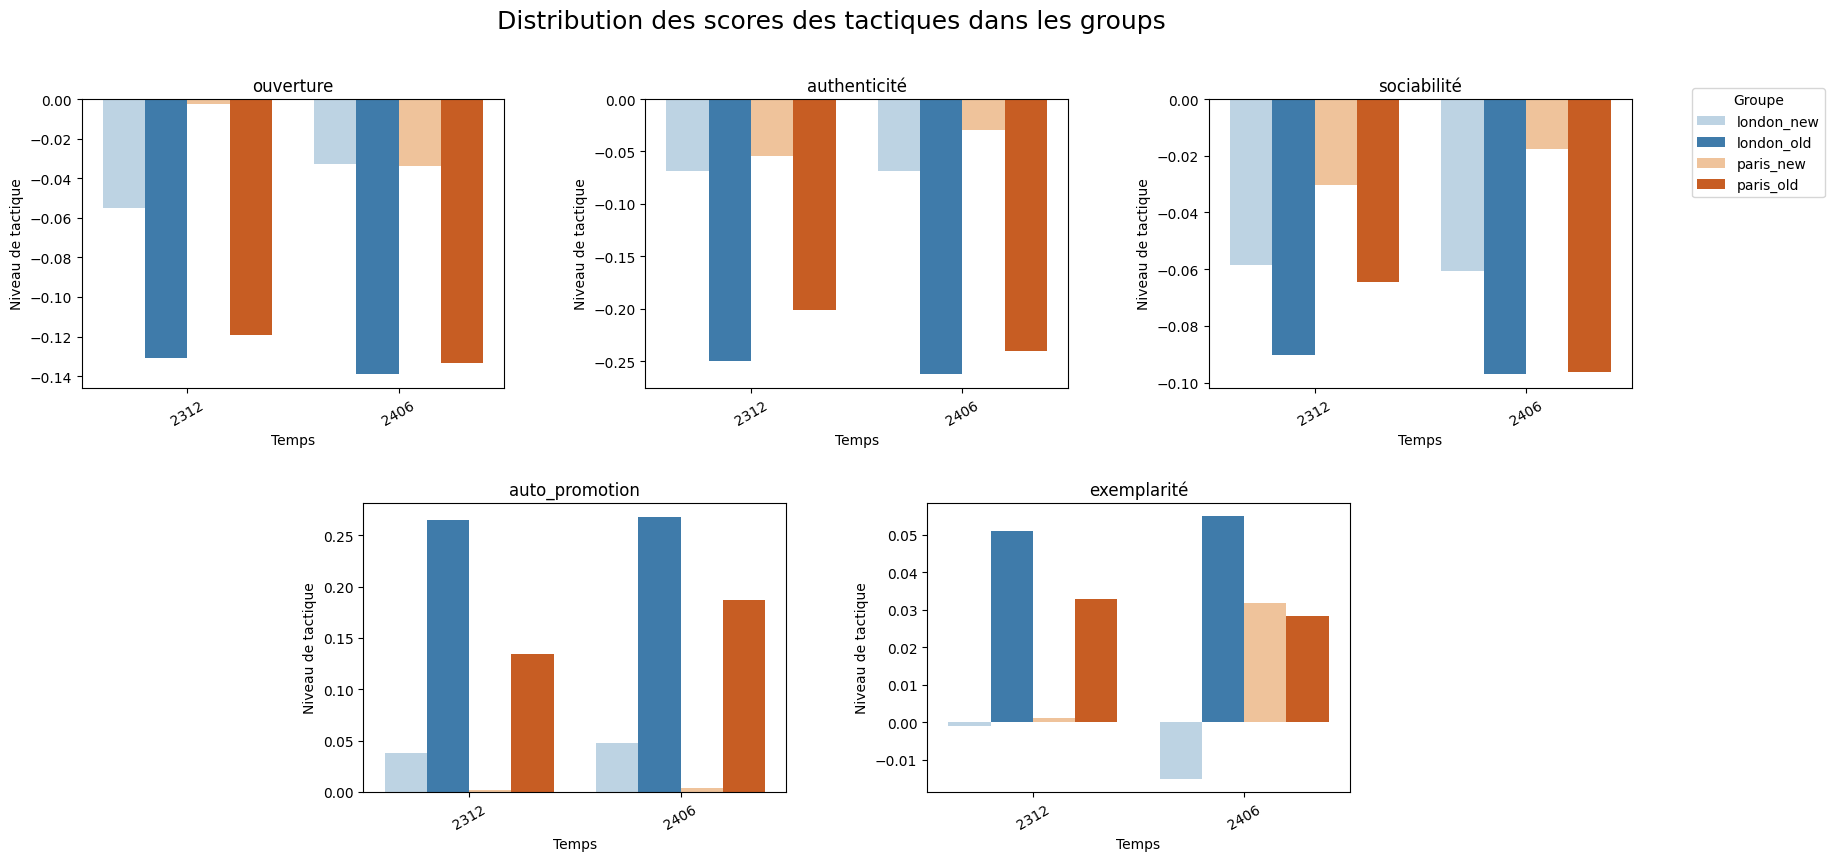

In [42]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## ---subplot layout---
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# ---data---
# var="authenticité"
# agg=df_plot.groupby(["time","group_pn",'is_new_host'])[var].mean().reset_index()
# agg.rename(columns={f"{var}":"value"}, inplace=True)
# print(agg)


# ---colors----
blue_cmap=plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.7, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.7, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
# groups=df_plot['group_pn'].unique()
# palette={k: v for k, v in zip (groups, colors)}


# ---plot---
# df_plot=sub_df.copy()
for i, var in enumerate(tactics_bio):
    print(var)
    ax=axes[i]
    agg=df_plot.groupby(["time","group_pn",'is_new_host'])[var].mean().reset_index()
    agg.rename(columns={f"{var}":"value"}, inplace=True)

    sns.barplot(
        data=agg,
        x='time',
        y="value",
        hue="group_pn",
        # palette=palette,
        ax=ax
    )
    ax.set_title(var)
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau de tactique")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()
    
    
fig.suptitle(
        "Distribution des scores des tactiques dans les groups",
        fontsize=18,
        y=0.98
    )
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Groupe", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0,0, 0.9,1])
plt.show()
    
    



In [ ]:
import matplotlib.gridspec as gridspec


## ---subplot layout---
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])


# ---colors---
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
# palette={k: v for k, v in zip (groups, colors)}



In [ ]:
# exemple de 2406
df_2406=df[df['time']==2406]
print(df_2406.shape)
print(df_2406[['time','in_paris','new_in_2406']].value_counts(dropna=False))


(112594, 127)
time  in_paris  new_in_2406
2406  0         0              37937
      1         0              34176
                1              28562
      0         1              11919
Name: count, dtype: int64


In [32]:
from utils import preprocess_listings
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
 
tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
tactic_pic= [
    "host_picture_type",
    "is_smiling"
]

#  --- num---
vars_ctrl_num=[
    'booking_rate_l90d',
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    'professional_host',
    "host_response_rate",
    "price","availability_90", 
    "years_since_host",
    "text_length",
]

# ---cat---
vars_ctrl_cat=[
    # cat
    "host_identity_verified",
    'host_is_superhost',
    'host_response_time',
    'room_type',"instant_bookable",    
    "has_text", "lang_en","lang_fr",    
    # "age_class","gender",
]


##
df_stats=df_2406.copy()
cols_to_check=vars_ctrl_num +tactics_bio

group_mean_table_ttest(df_stats, cols_to_check, group_col='new_in_2406',        
                    save=False, output_folder="mod_results", filename_noext=None)

#新进入，但不是有经验的房东



NameError: name 'df_2406' is not defined

In [71]:
agg=df_2406.groupby(['in_paris', 'new_in_2406'])[tactics_bio].mean().reset_index()
display(agg)

agg_long=agg.melt(
    id_vars=['in_paris','new_in_2406'],
    value_vars=tactics_bio,
    var_name='variable',
    value_name='value'
)
agg_long

,in_paris,new_in_2406,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,0,0,-0.138921,-0.262354,-0.096956,0.267661,0.054928
1,0,1,-0.032854,-0.068915,-0.060629,0.047285,-0.015097
2,1,0,-0.133475,-0.240384,-0.096182,0.186465,0.028441
3,1,1,-0.034036,-0.029554,-0.017548,0.003604,0.031944


,in_paris,new_in_2406,variable,value
0,0,0,ouverture,-0.138921
1,0,1,ouverture,-0.032854
2,1,0,ouverture,-0.133475
3,1,1,ouverture,-0.034036
4,0,0,authenticité,-0.262354
5,0,1,authenticité,-0.068915
6,1,0,authenticité,-0.240384
7,1,1,authenticité,-0.029554
8,0,0,sociabilité,-0.096956
9,0,1,sociabilité,-0.060629


In [94]:
sub=agg_long[agg_long['variable']=='authenticité']
sub

,in_paris,new_in_2406,variable,value
4,0,0,authenticité,-0.262354
5,0,1,authenticité,-0.068915
6,1,0,authenticité,-0.240384
7,1,1,authenticité,-0.029554


Text(0.5, 1.0, 'authenticité')

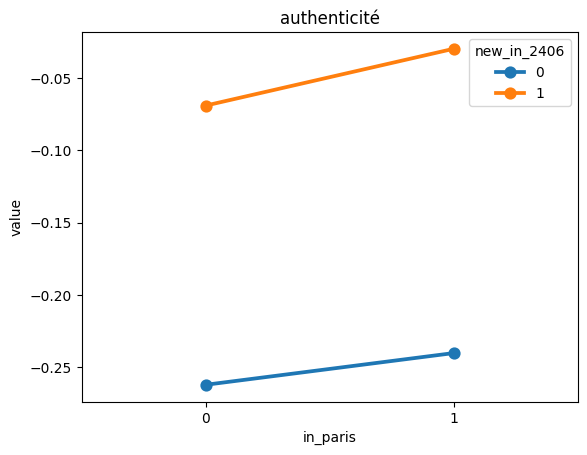

In [97]:
sns.pointplot(
    data=sub,
    x="in_paris",
    y="value",
    hue="new_in_2406",
    errorbar=("ci", 95),
)
plt.title('authenticité')


<Axes: xlabel='in_paris', ylabel='value'>

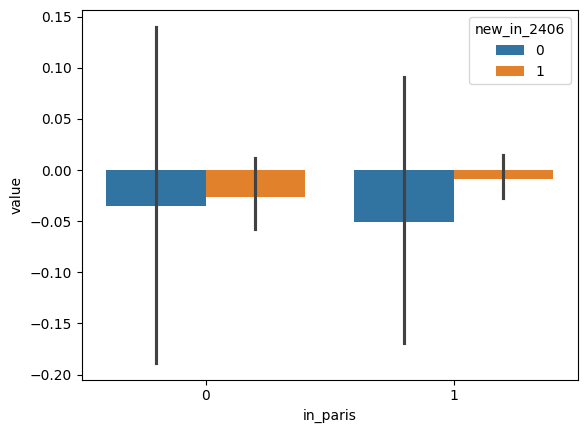

In [ ]:

sns.barplot(
    data=agg_long,
    x="in_paris",
    y="value",
    hue="new_in_2406",
)
plt.xlabel()

0 ouverture


,in_paris,new_in_2406,variable,value
0,0,0,ouverture,-0.138921
1,0,1,ouverture,-0.032854
2,1,0,ouverture,-0.133475
3,1,1,ouverture,-0.034036


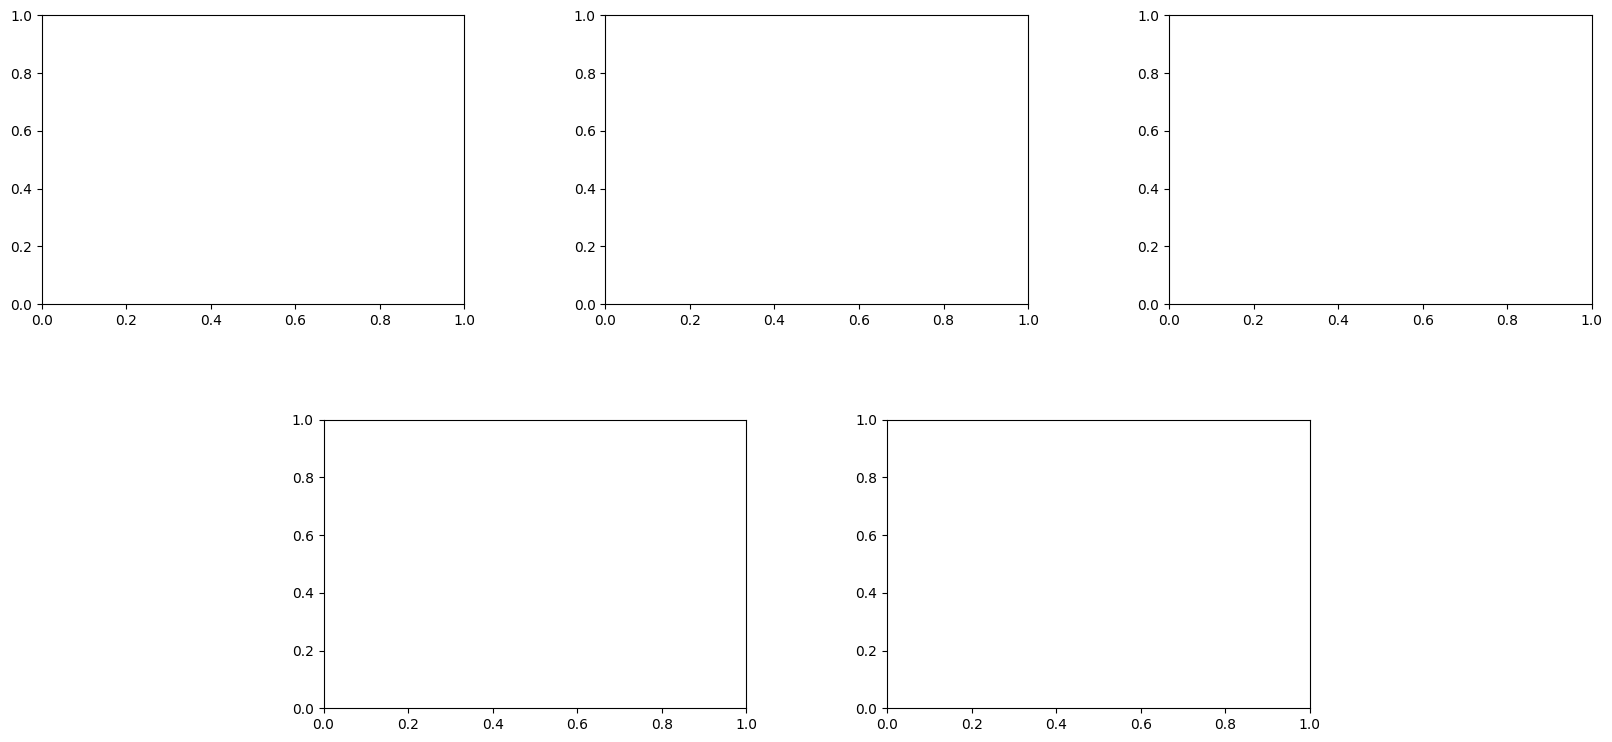

In [83]:
import matplotlib.gridspec as gridspec


# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


df_plot=agg_long.copy()

for i, var in enumerate(tactics_bio):
    print(i, var)
    sub=df_plot[df_plot['variable']==var]
    display(sub)
    
    # ax.plot(
    #     sub['']
    # )
    # sns.barplot(
    #     data=agg_long,
    #     x="in_paris",
    #     y="value",
    #     hue="new_in_2406",
    #     ax=axes[i],
    #     label=f"{'nouveaux entrant' if new_in_2406==1 else 0}"
    # )
    # axes[i].legend().remove()
    break


# handles,labels=axes[0].get_legend_handels_labels()

# sns.catplot(
#     data=agg_long,
#     kind="bar",
#     x="in_paris",
#     y="value",
#     hue="new_in_2406",
#     col="variable",
#     ax=ax,
#     # palette=["tab:blue","tab:orange"]
#     palette=[london_colors[2], paris_colors[2]]
# )